# 06 — Analisis Penjualan Global Superstore

Sebagai **analis bisnis**, kita akan membedah data penjualan Superstore untuk menjawab pertanyaan penting: kategori produk mana yang paling menguntungkan? Wilayah mana yang berkinerja terbaik? Adakah sub-kategori yang justru **merugi**?

> 🎯 **Tujuan Pembelajaran**
> - Membuat **pivot table** untuk meringkas penjualan & profit.
> - Menghitung **margin keuntungan** (profit / sales).
> - Menemukan sub-kategori yang merugi.
> - Mem-parsing tanggal untuk melihat **tren bulanan**.
> - Memvisualisasikan profit per kategori, heatmap region×kategori, dan tren waktu.



## 📊 Tentang Dataset

Dataset **Sample - Superstore** berisi ~10.000 transaksi penjualan ritel (furnitur, office supplies, teknologi) di Amerika Serikat. File memakai encoding **latin-1**.

- **Sumber:** [Kaggle — vivek468/superstore-dataset-final](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

| Kolom | Arti |
|-------|------|
| `Order Date` | Tanggal pesanan |
| `Ship Date` | Tanggal pengiriman |
| `Segment` | Segmen pelanggan (Consumer, Corporate, Home Office) |
| `Region` | Wilayah (East, West, Central, South) |
| `Category` | Kategori produk |
| `Sub-Category` | Sub-kategori produk |
| `Sales` | Nilai penjualan |
| `Quantity` | Jumlah unit |
| `Discount` | Diskon |
| `Profit` | Keuntungan (bisa negatif = rugi) |

## 1. Import Library

- **pandas** → olah tabel, pivot, tanggal. • **numpy** → angka. • **matplotlib**/**seaborn** → grafik.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download vivek468/superstore-dataset-final

Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
100% 550k/550k [00:00<00:00, 53.4MB/s]



In [5]:
#Unzip
!unzip -q superstore-dataset-final.zip

replace Sample - Superstore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [6]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
print(df.shape)
print(df.info())

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

Interpretasi

Dataset terdiri dari 21 Kolom, dan 9994 Baris
- Tiap baris adalah data 1 item dalam 1 pesanan, lengkap dengan value penjualan dan Keuntungannya
- Tidak terdapat missing value
- 15 Colom bertipe data Objek


In [11]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


Interpretasi:
  - terdapat indikasi 1 kerugian yang sangat besar dikolom profit
  - rata rata penjualan diangka 230

In [13]:
#Memastikan missing value
df.isna().sum().sum()

np.int64(0)

Interpretasi

data bersih dari nilai yang hilang

## Pembersihan & Persiapan Data

Kita ubah `Order Date` jadi datetime dan buat kolom periode bulanan untuk analisis tren.

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Periode"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

#print date min - max
print(df["Order Date"].min())
print(df["Order Date"].max())
df[["Order Date", "Periode"]].head()

2014-01-03 00:00:00
2017-12-30 00:00:00


,Order Date,Periode
0,2016-11-08,2016-11-01
1,2016-11-08,2016-11-01
2,2016-06-12,2016-06-01
3,2015-10-11,2015-10-01
4,2015-10-11,2015-10-01


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Interpretasi

- Kolom Periode akan digunakan untuk resampling trend bulanan dari penjualan dan profit tiap bulannya

## EDA dan Visualisasi

### Pivot Table: Total Sales dan Profit per Kategori barang

In [19]:
pvt_cat = df.pivot_table(index="Category", values=["Sales", "Profit"],
                         aggfunc="sum").sort_values("Profit", ascending=False)
pvt_cat["Margin (%)"] = round(pvt_cat["Profit"] / pvt_cat["Sales"] * 100, 2)
pvt_cat

,Profit,Sales,Margin (%)
Category,,,
Technology,145454.9481,836154.0330,17.40
Office Supplies,122490.8008,719047.0320,17.04
Furniture,18451.2728,741999.7953,2.49


Interpretasi:
  - Kategori Teknologi dan Office Supply Memberikan Profit Tertinggi
  - Kategori Funiture Memiliki Profit Margin yang tipis dari Sales
  

### Visualisai Profit per Kategori

/tmp/ipykernel_423/2484923381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pvt_cat.index, y=pvt_cat["Profit"], palette="mako")


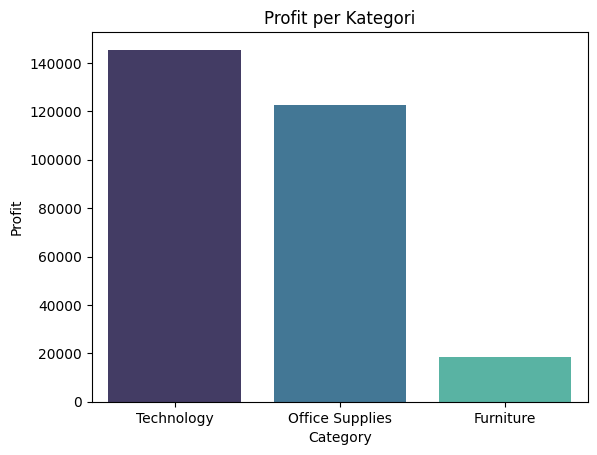

In [22]:
#Visualisai Profit per Kategoori

sns.barplot(x=pvt_cat.index, y=pvt_cat["Profit"], palette="mako")
plt.title("Profit per Kategori")
plt.show()

Interpretasi:

  -  Teknologi memiliki profit margin terbesar
  -  Funiture memiliki profit margin paling kecil

###Sales vs Segment

In [45]:
#Pivot Sales vs Segment
pvt_seg = df.pivot_table(index="Segment",
                         values=["Sales", "Profit"],
                         aggfunc="sum").sort_values("Profit", ascending=False)
pvt_seg["Margin (%)"] = round(pvt_seg["Profit"] / pvt_seg["Sales"] * 100, 2)
pvt_seg
#

,Profit,Sales,Margin (%)
Segment,,,
Consumer,134119.2092,1.161401e+06,11.55
Corporate,91979.1340,7.061464e+05,13.03
Home Office,60298.6785,4.296531e+05,14.03


Interpretasi:
  - tidak terdapat selisih Margin yang besar antar segment
  - Segment Home Office mendapat margin profit terbesar

/tmp/ipykernel_423/567996649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pvt_seg.index, y=pvt_seg["Margin (%)"], palette="mako")


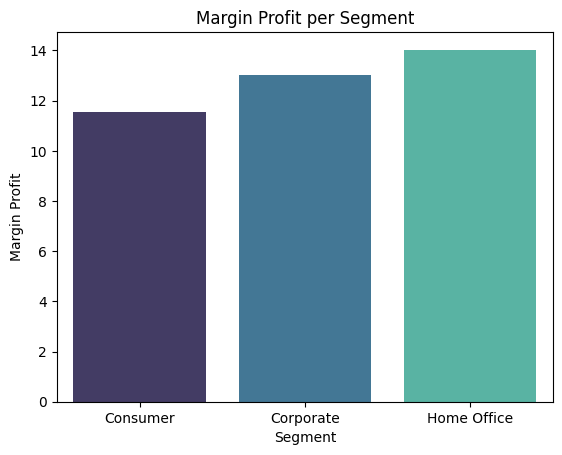

In [48]:
#Visualisai Profit per Segmen
sns.barplot(x=pvt_seg.index, y=pvt_seg["Margin (%)"], palette="mako")
plt.title("Margin Profit per Segment")
plt.xlabel("Segment")
plt.ylabel("Margin Profit")
plt.show()

Interpretasi:


###Sub Kategori Margin

In [23]:
pvt_sub_cat = df.pivot_table(index="Sub-Category", values=["Sales", "Profit"],
                             aggfunc="sum").sort_values("Profit", ascending=False)

pvt_sub_cat["Margin (%)"] = round(pvt_sub_cat["Profit"] / pvt_sub_cat["Sales"] * 100, 2)
pvt_sub_cat.head()

,Profit,Sales,Margin (%)
Sub-Category,,,
Copiers,55617.8249,149528.030,37.20
Phones,44515.7306,330007.054,13.49
Accessories,41936.6357,167380.318,25.05
Paper,34053.5693,78479.206,43.39
Binders,30221.7633,203412.733,14.86


In [24]:
#Merugi
pvt_sub_cat[pvt_sub_cat["Margin (%)"] < 0].sort_values("Margin (%)")


,Profit,Sales,Margin (%)
Sub-Category,,,
Tables,-17725.4811,206965.5320,-8.56
Bookcases,-3472.5560,114879.9963,-3.02
Supplies,-1189.0995,46673.5380,-2.55


### Visualisasikan Sub categori yang untung dan rugi

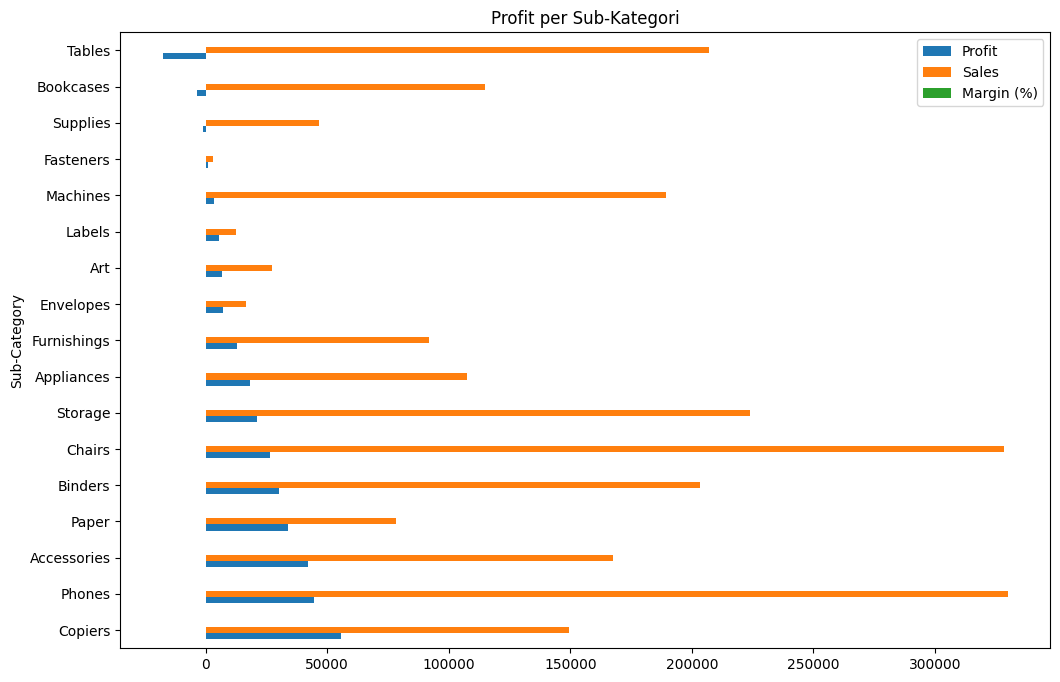

In [32]:
pvt_sub_cat.plot(kind="barh", figsize=(12,8))
plt.title("Profit per Sub-Kategori")
plt.show()

Interpretasi:

  -  Table, Bookcase, dan Supplies. Memiliki Margin dibawah nol, yang mengindikasikan kerugian terhadap penjualan
  - Chair dan Phone memiliki Total Profit Margin Penjualan paling besar dari Penjualan

### Heatmap Profit: Region dengan Categori

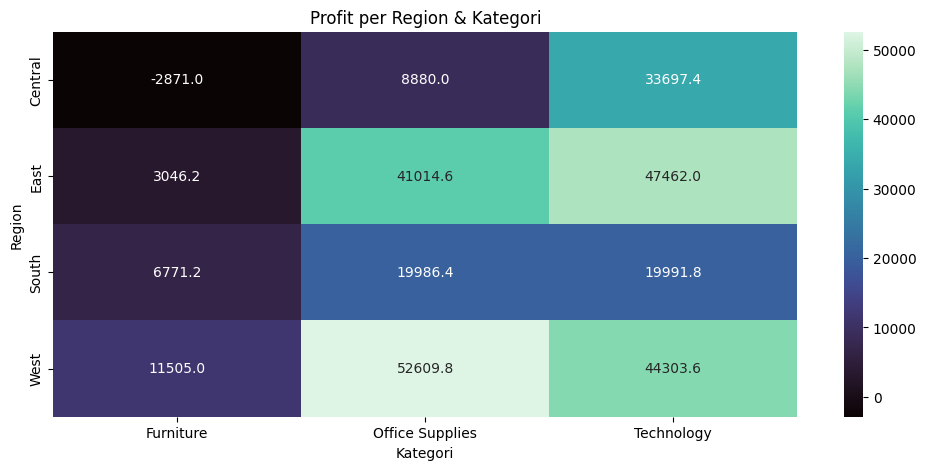

In [36]:
pvt_reg_cat = df.pivot_table(index="Region",
                             columns="Category",
                             values="Profit",
                             aggfunc="sum")

plt.figure(figsize=(12,5))
sns.heatmap(pvt_reg_cat, cmap="mako", annot=True, fmt=".1f")
plt.title("Profit per Region & Kategori")
plt.xlabel("Kategori")
plt.ylabel("Region")
plt.show()

Interpretasi:
  - Untuk Bagian Central, Memiliki Profit minus untuk kategory Funiture, artinya tidak ada keuntungan untuk wilayah ini untuk kategory Funiture
  - Untuk Profit Tertinggi ada di 2 Wilayah West dan East. dari Catergory Office Supply dan Technology

### Tren Penjualan Bulanan(Line Chart)

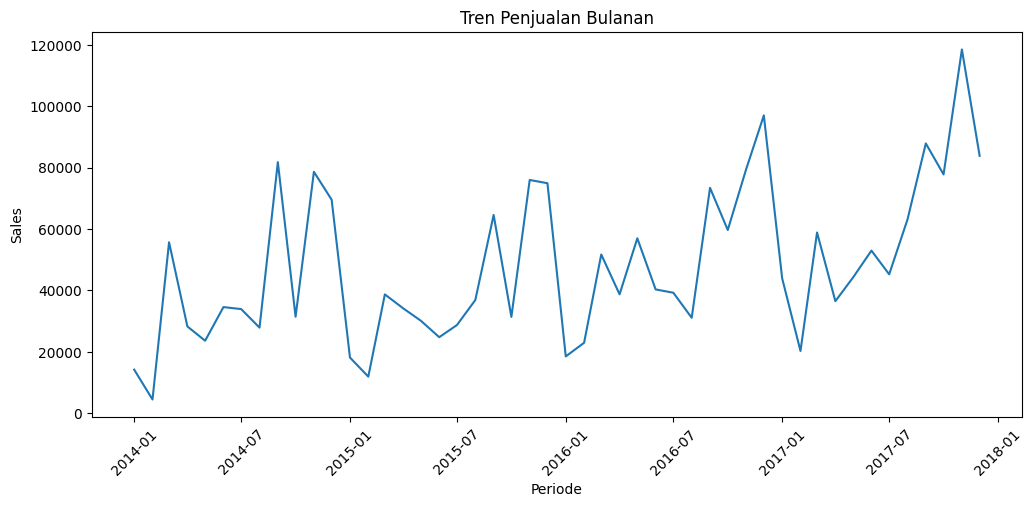

In [44]:
trnd_month = df.groupby("Periode")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(x="Periode", y="Sales", data=trnd_month)
plt.xticks(rotation=45)
plt.title("Tren Penjualan Bulanan")
plt.show()

Interpretasi:

- Terdapat Siklus Peningkatan di akhir tahun dan setelahnya mengalami penurunan menjelang pergantian tahun
- Dari Lineplot penjualan mengalami kenaikan dari awal pencatatan

Interpretasi:

## Kesimpulan & Insight

  - **Technology** adalah kategori paling menguntungkan; **Furniture** untungnya tipis.
  - Sub-kategori **Tables, Bookcases, Supplies** justru **merugi** → perlu evaluasi harga/diskon.
  - Wilayah **West & East** paling menguntungkan; **Central** relatif lemah pada Furniture.
  - Penjualan tumbuh dari tahun ke tahun dengan **puncak musiman di akhir tahun**.
  - Rekomendasi bisnis: tinjau ulang diskon pada sub-kategori rugi & perkuat kategori Technology.

## 💼 Rekomendasi & Insight Bisnis (lanjutan)

Selain meninjau diskon pada sub-kategori yang merugi, manajer dapat **menetapkan batas diskon
maksimum** per kategori dan mengalihkan anggaran promosi ke produk bermargin sehat. Memetakan
profit per wilayah × kategori (heatmap) memudahkan keputusan **di mana** harus ekspansi dan
**di mana** harus berhemat.

### ⚠️ Jebakan Data
- `Profit` bisa **negatif**. Memakai rata-rata atau total saja bisa menyembunyikan transaksi rugi —
  selalu cek nilai minimum & jumlah baris rugi.
- Diskon berkorelasi **negatif** dengan profit. Jangan menyimpulkan "diskon = penjualan naik = bagus"
  tanpa melihat dampaknya ke profit; volume naik tapi margin bisa habis.